# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [1]:
!pip install sqlalchemy
!pip install psycopg2-binary

In [2]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
from dotenv import load_dotenv 
import os  
import psycopg2
load_dotenv()

True

In [4]:
print(str(os.environ.get('PASSWORD')))
print(str(os.environ.get('USER')))
print(str(os.environ.get('HOST')))
print(str(os.environ.get('PORT')))
print(str(os.environ.get('DATABASE')))

Sdf4$2;d-d30pp
germangedymin
rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net
6432
data-analyst-afisha


In [18]:
 db_config = {'user' : 'praktikum_student',
             'pwd' : os.environ.get('PASSWORD'),
             'host' : os.environ.get('HOST'),
             'port' : os.environ.get('PORT'),
             'db' : os.environ.get('DATABASE') }

In [19]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [14]:
engine = create_engine(connection_string)


In [15]:
query = '''WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
) 
select p.user_id, 
       p.device_type_canonical,
       p.order_id,
       p.created_dt_msk,
       p.created_ts_msk,
       p.currency_code,
       p.revenue,
       p.tickets_count,
     case 
         when (created_dt_msk::date - lag(created_dt_msk::date) over(partition by user_id ORDER BY created_dt_msk))::numeric > 0 then created_dt_msk::date - lag(created_dt_msk::date) over(partition by user_id ORDER BY created_dt_msk)
     else null
  end as days_since_prev,
      p.event_id,
      e.event_name_code as event_name,
      e.event_type_main,
      p.service_name,
      r.region_name,
      c.city_name
  from afisha.purchases p 
  inner join afisha.events e using(event_id)
  inner join afisha.city c using (city_id)
  inner join afisha.regions r using(region_id)
where device_type_canonical in ('mobile','desktop') and e.event_type_main != 'фильм'
order by user_id '''

In [ ]:
df = pd.read_sql_query(query,con=engine) #проблемы с подключением не в москве, gkj

In [ ]:
df.head()

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   created_dt_msk         290611 non-null  datetime64[ns]
 4   created_ts_msk         290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        84626 non-null   float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [18]:
print('Минимальное количество купленных билетов', min(df['tickets_count'])) 
print('Максимальное количество купленных билетов', max(df['tickets_count']))

Минимальное количество купленных билетов 1
Максимальное количество купленных билетов 57


 - Из информации по датафрейму видно, что пропуски в столбце tickets_count отсутствуют, количество билетов изменяется от 1 до 57.  Можно изменить тип данных с float64 на более оптимальный
 - аосмотреть количкство пропусков в созданном нами столбце days_since_prev
 - сделать проверку явных и не явных дубликатов

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [13]:
df['tickets_count'] = pd.to_numeric(df['tickets_count'],downcast = 'integer')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   created_dt_msk         290611 non-null  datetime64[ns]
 4   created_ts_msk         290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        84626 non-null   float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [14]:
df.isna().sum()

user_id                       0
device_type_canonical         0
order_id                      0
created_dt_msk                0
created_ts_msk                0
currency_code                 0
revenue                       0
tickets_count                 0
days_since_prev          205985
event_id                      0
event_name                    0
event_type_main               0
service_name                  0
region_name                   0
city_name                     0
dtype: int64

In [15]:
df.isna().sum()/ df.shape[0]

user_id                  0.0000
device_type_canonical    0.0000
order_id                 0.0000
created_dt_msk           0.0000
created_ts_msk           0.0000
currency_code            0.0000
revenue                  0.0000
tickets_count            0.0000
days_since_prev          0.7088
event_id                 0.0000
event_name               0.0000
event_type_main          0.0000
service_name             0.0000
region_name              0.0000
city_name                0.0000
dtype: float64

 - количесво пропусков 70 %, что может быть обьяснено тем, что многие клиенты делали только 1 заказ

In [16]:
df[['user_id','order_id']].duplicated().sum()

0

Явные дубликаты отсцтствуют по столбцам - ключам (user_id,order_id)

In [17]:
df['user_id'] = df['user_id'].str.lower()
df['user_id'] = df['user_id'].str.strip()

In [18]:
df[['user_id','order_id']].duplicated().sum()

0

**Дубликаты не обнаружены**

In [19]:
df_valute = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
df_valute

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
...,...,...,...,...
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt


In [20]:
def convert_to_rub(row, rate_df):
    if row['currency_code'] == 'kzt':
        # Ищем курс для текущей даты
        rate_row = rate_df[rate_df['data'] == row['created_dt_msk']]
        if not rate_row.empty:
            curs = rate_row['curs'].iloc[0]
            return row['revenue'] / (curs / 100)
    return row['revenue']

df['revenue_rub'] = df.apply(lambda row: convert_to_rub(row, df_valute), axis=1)


In [21]:
df[df['currency_code'] == 'kzt']

,user_id,device_type_canonical,order_id,created_dt_msk,created_ts_msk,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
70,0033403583a55ed,mobile,7850214,2024-09-17,2024-09-17 16:52:06,kzt,518.10,4,20.0,559919,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,другое,Билеты без проблем,Верхоречная область,Серебрянка,518.10
89,0040e12d70fae81,desktop,8634925,2024-09-02,2024-09-02 19:49:14,kzt,347.18,3,39.0,559476,61ec7c0e-ea0c-4a3e-a63a-09cbe1bc6177,другое,Билеты без проблем,Верхоречная область,Серебрянка,347.18
96,0054b38b2653e6e,mobile,7625522,2024-09-09,2024-09-09 18:06:04,kzt,328.77,4,NaN,559582,524f434e-0381-4f47-9688-7c4e41961b65,другое,Билеты без проблем,Верхоречная область,Серебрянка,328.77
277,00f4f5244501ce6,mobile,720419,2024-06-11,2024-06-11 20:15:57,kzt,22021.55,5,NaN,536826,76af4f88-c554-4e9e-9df4-1cc8aeec8959,концерты,Мой билет,Верхоречная область,Серебрянка,22021.55
460,01370a0e9c1a7d5,desktop,5227657,2024-06-04,2024-06-04 13:28:17,kzt,7397.66,4,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,7397.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290484,ffc24188a1d58f2,mobile,6862648,2024-07-11,2024-07-11 12:39:48,kzt,4735.52,2,20.0,538828,603c97c6-b64f-4ec6-8de9-20b95c20b2b5,концерты,Билеты без проблем,Верхоречная область,Серебрянка,4735.52
290485,ffc24188a1d58f2,mobile,6763294,2024-09-05,2024-09-05 12:07:00,kzt,4735.52,2,56.0,538828,603c97c6-b64f-4ec6-8de9-20b95c20b2b5,концерты,Билеты без проблем,Верхоречная область,Серебрянка,4735.52
290486,ffc24188a1d58f2,mobile,3984021,2024-09-06,2024-09-06 19:20:03,kzt,1849.41,1,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,1849.41
290488,ffc4133fbba20f4,mobile,8493898,2024-06-21,2024-06-21 13:41:39,kzt,3698.83,2,NaN,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,3698.83


 **Был создан новый столбец revenue_rub с преведенными ценами к рублю**

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [22]:
df.isna().sum()

user_id                       0
device_type_canonical         0
order_id                      0
created_dt_msk                0
created_ts_msk                0
currency_code                 0
revenue                       0
tickets_count                 0
days_since_prev          205985
event_id                      0
event_name                    0
event_type_main               0
service_name                  0
region_name                   0
city_name                     0
revenue_rub                   0
dtype: int64

In [23]:
df.isna().sum()/ df.shape[0]

user_id                  0.0000
device_type_canonical    0.0000
order_id                 0.0000
created_dt_msk           0.0000
created_ts_msk           0.0000
currency_code            0.0000
revenue                  0.0000
tickets_count            0.0000
days_since_prev          0.7088
event_id                 0.0000
event_name               0.0000
event_type_main          0.0000
service_name             0.0000
region_name              0.0000
city_name                0.0000
revenue_rub              0.0000
dtype: float64

In [24]:
df.head()

,user_id,device_type_canonical,order_id,created_dt_msk,created_ts_msk,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41


In [25]:
print(df['currency_code'].value_counts())
print(df['device_type_canonical'].value_counts())
print(df['event_type_main'].value_counts())
print(df['service_name'].value_counts().reset_index().sort_values(by = 'index'))

rub    285542
kzt      5069
Name: currency_code, dtype: int64
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64
                     index  service_name
19           Crazy ticket!           790
14             Show_ticket          2200
27       Билет по телефону            85
0       Билеты без проблем         63519
35      Билеты в интернете             4
2            Билеты в руки         40343
16             Быстробилет          2003
22          Быстрый кассир           381
6           Весь в билетах         16849
18               Восьмёрка          1118
28                 Вперёд!            80
17          Выступления.ру          1616
13  Городской дом культуры          2733
11            Дом культуры          4502
29                 Дырокол            74
12             За билетом!         

**В категориальных даннах нет ошибок**

In [26]:
df[['tickets_count','revenue_rub','days_since_prev']].describe().reset_index()

,index,tickets_count,revenue_rub,days_since_prev
0,count,290611.000000,290611.000000,84626.000000
1,mean,2.754311,625.584360,10.230697
2,std,1.170620,1227.693064,18.366712
3,min,1.000000,-90.760000,1.000000
4,25%,2.000000,116.850000,1.000000
5,50%,3.000000,356.010000,3.000000
6,75%,4.000000,810.130000,10.000000
7,max,57.000000,81174.540000,148.000000


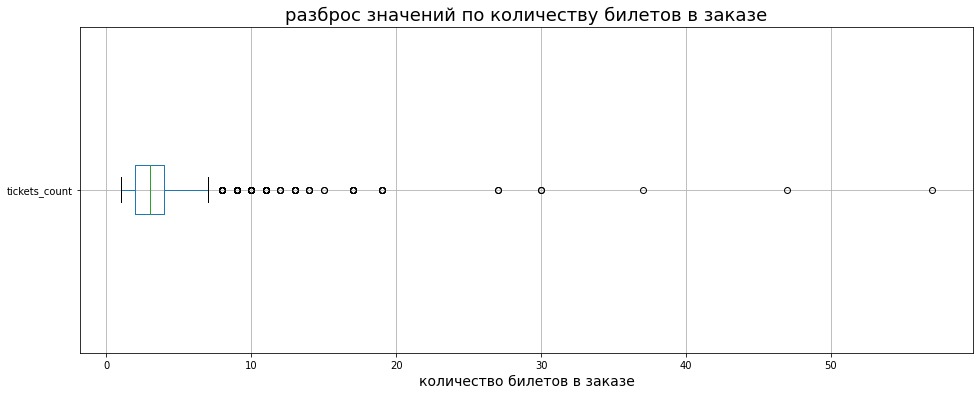

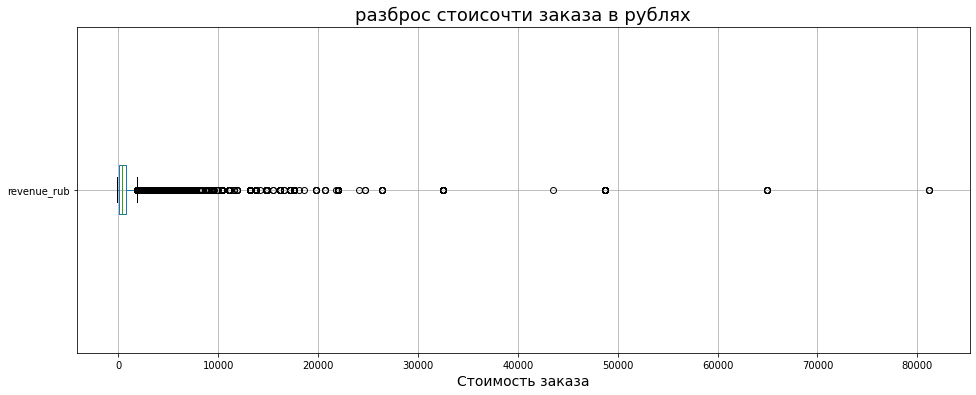

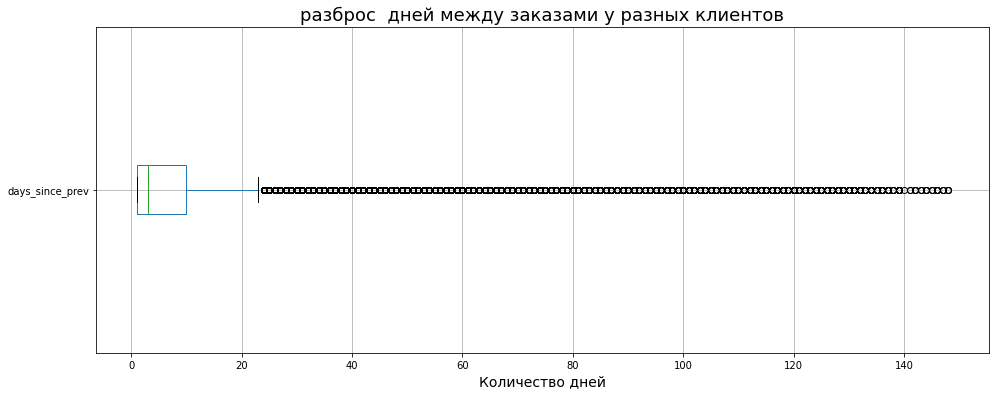

In [27]:
df.boxplot(column = 'tickets_count', vert = False,figsize = (16,6))
plt.title('разброс значений по количеству билетов в заказе', fontsize = 18)
plt.xlabel('количество билетов в заказе', fontsize = 14)
plt.show()
df.boxplot(column = 'revenue_rub', vert = False,figsize = (16,6))
plt.title('разброс стоисочти заказа в рублях', fontsize = 18)
plt.xlabel('Стоимость заказа', fontsize = 14)
plt.show()
df.boxplot(column = 'days_since_prev', vert = False,figsize = (16,6))
plt.title('разброс  дней между заказами у разных клиентов', fontsize = 18)
plt.xlabel('Количество дней', fontsize = 14)
plt.show()


**Выбросы присутствуют во всех числовых значениях.**



In [28]:
pro_99 = df['revenue_rub'].quantile(0.99)
print(pro_99)
df = df[df['revenue_rub'] <= pro_99 ]
df['revenue_rub'].describe()

4003.133000000076


count    287704.000000
mean        538.079489
std         564.198785
min         -90.760000
25%         115.470000
50%         347.950000
75%         794.800000
max        4000.190000
Name: revenue_rub, dtype: float64

 **Промежуточный итог**
 - Были проверены категориальные данные. В них нет ошибок
 - Были проверены числовые данные. во всех данных присутствуют (правый хвост)
 - в столбце revenue_rub были отобранны данные до 99 процентиля включительно

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [29]:
df_sort = df.sort_values(by = ['user_id','created_ts_msk'])
df_sort.head()

,user_id,device_type_canonical,order_id,created_dt_msk,created_ts_msk,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41


In [30]:
df_profile = df_sort.groupby('user_id')['created_ts_msk'].agg(['min','max']).reset_index()

In [31]:
df_profile = df_profile.rename(columns = {'min' : 'min_created_ts_msk',
                                         'max' : 'max_created_ts_msk'})
df_profile

,user_id,min_created_ts_msk,max_created_ts_msk
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04
...,...,...,...
21764,fff13b79bd47d7c,2024-07-16 22:17:10,2024-10-31 18:31:52
21765,fff32fc9ad0f9f6,2024-08-15 14:36:28,2024-10-28 23:40:38
21766,fffcd3dde79eb2c,2024-06-20 19:57:25,2024-10-30 13:37:43
21767,fffeeb3c120cf0b,2024-09-24 10:07:42,2024-09-24 10:07:42


In [32]:
df_sort_users = df_sort
df_sort_users = df_sort_users.drop_duplicates(subset = 'user_id').reset_index()
df_sort_users_agg = df_sort_users[['user_id','device_type_canonical','region_name','service_name','event_type_main']]
df_sort_users_agg
df_profile = df_profile.merge(df_sort_users_agg,on = 'user_id')


In [33]:
df_count_orders = df_sort.groupby('user_id')['order_id'].count()
df_profile = df_profile.merge(df_count_orders, on = 'user_id')


In [34]:
df_avg_revenue = df_sort.groupby('user_id')['revenue_rub'].mean()
df_profile = df_profile.merge(df_avg_revenue, on = 'user_id')


In [35]:
df_avg_tickets = df_sort.groupby('user_id')['tickets_count'].mean()
df_profile = df_profile.merge(df_avg_tickets, on = 'user_id')


In [36]:
df_sort['time_diff'] = df_sort['created_ts_msk'].diff()
def get_avg_diff(group):
    dates = group['created_ts_msk'].sort_values()
    diffs = dates.diff().dropna()
    return diffs.mean() if not diffs.empty else pd.NaT

user_avg = df_sort.groupby('user_id').apply(get_avg_diff).reset_index()
user_avg = user_avg.rename(columns = {0 : 'avg_time'})
df_profile = df_profile.merge(user_avg, on = 'user_id')
df_profile


,user_id,min_created_ts_msk,max_created_ts_msk,device_type_canonical,region_name,service_name,event_type_main,order_id,revenue_rub,tickets_count,avg_time
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaT
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,74 days 19:19:38
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,50 days 21:45:36
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaT
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,15 days 14:49:52
...,...,...,...,...,...,...,...,...,...,...,...
21764,fff13b79bd47d7c,2024-07-16 22:17:10,2024-10-31 18:31:52,mobile,Каменевский регион,Мой билет,другое,9,688.043333,2.555556,13 days 08:31:50.250000
21765,fff32fc9ad0f9f6,2024-08-15 14:36:28,2024-10-28 23:40:38,desktop,Каменевский регион,Билеты без проблем,стендап,2,850.995000,2.500000,74 days 09:04:10
21766,fffcd3dde79eb2c,2024-06-20 19:57:25,2024-10-30 13:37:43,desktop,Каменевский регион,Билеты без проблем,концерты,33,557.908485,2.787879,4 days 02:48:08.062500
21767,fffeeb3c120cf0b,2024-09-24 10:07:42,2024-09-24 10:07:42,desktop,Широковская область,Билеты без проблем,стендап,1,661.530000,2.000000,NaT


In [37]:
def is_two(column):
    if column < 2:
        return 0
    else:
        return 1
def is_five (column):
    if column < 5:
        return 0
    else:
        return 1
df_profile['is_two'] = df_profile['tickets_count'].apply(is_two)
df_profile['is_five'] = df_profile['tickets_count'].apply(is_five)  
df_profile

,user_id,min_created_ts_msk,max_created_ts_msk,device_type_canonical,region_name,service_name,event_type_main,order_id,revenue_rub,tickets_count,avg_time,is_two,is_five
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaT,1,0
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,74 days 19:19:38,1,0
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,50 days 21:45:36,1,0
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaT,1,0
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,15 days 14:49:52,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21764,fff13b79bd47d7c,2024-07-16 22:17:10,2024-10-31 18:31:52,mobile,Каменевский регион,Мой билет,другое,9,688.043333,2.555556,13 days 08:31:50.250000,1,0
21765,fff32fc9ad0f9f6,2024-08-15 14:36:28,2024-10-28 23:40:38,desktop,Каменевский регион,Билеты без проблем,стендап,2,850.995000,2.500000,74 days 09:04:10,1,0
21766,fffcd3dde79eb2c,2024-06-20 19:57:25,2024-10-30 13:37:43,desktop,Каменевский регион,Билеты без проблем,концерты,33,557.908485,2.787879,4 days 02:48:08.062500,1,0
21767,fffeeb3c120cf0b,2024-09-24 10:07:42,2024-09-24 10:07:42,desktop,Широковская область,Билеты без проблем,стендап,1,661.530000,2.000000,NaT,1,0


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [38]:
df_profile['user_id'].count()

21769

In [39]:
round(df_profile['revenue_rub'].mean(),2)

574.52

In [40]:
round(df_profile['is_two'].sum()/df_profile.shape[0],2)

0.89

In [41]:
round(df_profile['is_five'].sum()/df_profile.shape[0],2)

0.03

По данным профилей пользователей:

- общее количество пользоватклкй 21769

- средняя стоймость одного заказа 574.52 рубля

- доля полльзователей сделавших 2 и более заказоа 0.89

- доля пользователей сделавших 5 и более заказоа 0.03

In [42]:
print(df_profile['order_id'].describe())
print(df_profile['tickets_count'].describe())
print(df_profile['avg_time'].describe())
print('99 процентиль количества заказов у поьзователя', df_profile['order_id'].quantile(0.99))
print('95 процентиль количества заказов у поьзователя',df_profile['order_id'].quantile(0.95))
print('99 процентиль время между заказами к пользователя', df_profile['avg_time'].quantile(0.99))
print('95 процентиль время между заказами к пользователя', df_profile['avg_time'].quantile(0.95))

count    21769.000000
mean        13.216225
std        122.135348
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10207.000000
Name: order_id, dtype: float64
count    21769.000000
mean         2.748374
std          0.921696
min          1.000000
25%          2.000000
50%          2.750000
75%          3.111111
max         11.000000
Name: tickets_count, dtype: float64
count                         13443
mean     15 days 20:47:06.906396626
std      22 days 07:40:50.508018590
min                 0 days 00:00:01
25%          1 days 01:04:14.475000
50%                 8 days 02:47:45
75%      20 days 12:14:39.666666666
max               148 days 05:27:58
Name: avg_time, dtype: object
99 процентиль количества заказов у поьзователя 151.3199999999997
95 процентиль количества заказов у поьзователя 32.0
99 процентиль время между заказами к пользователя 112 days 19:25:45.480000
95 процентиль время между заказами к пользователя 61 days 11:52:28.2499

В приведенных данных в количестве заказов и времени между заказами есть большие выбросы

- данные по количеству заказов будут отфильтроываны по 99 процентилю

In [43]:
order_99 = df_profile['order_id'].quantile(0.99)
time_99 = df_profile['avg_time'].quantile(0.99)
df_profile = df_profile[(df_profile['order_id'] <= order_99)]
df_profile['user_id'].count()

21551

In [44]:
round(df_profile['revenue_rub'].mean(),2)

574.94

In [45]:
round(df_profile['is_two'].sum()/df_profile.shape[0],2)

0.89

In [46]:
round(df_profile['is_five'].sum()/df_profile.shape[0],2)

0.03

после сортировки по 99 процентилю  статические показатели почти не изменились

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [47]:
df_profile_sort = df_profile.groupby(['event_type_main','device_type_canonical','region_name','service_name'])['user_id'].count().reset_index()
df_profile_sort['dola'] = df_profile_sort['user_id']/df_profile_sort['user_id'].sum()
df_profile_sort

,event_type_main,device_type_canonical,region_name,service_name,user_id,dola
0,выставки,desktop,Каменевский регион,Show_ticket,1,0.000046
1,выставки,desktop,Каменевский регион,Билеты без проблем,2,0.000093
2,выставки,desktop,Каменевский регион,Билеты в руки,1,0.000046
3,выставки,desktop,Каменевский регион,Дом культуры,3,0.000139
4,выставки,desktop,Каменевский регион,КарандашРУ,1,0.000046
...,...,...,...,...,...,...
1734,ёлки,mobile,Широковская область,Быстрый кассир,3,0.000139
1735,ёлки,mobile,Широковская область,Дом культуры,10,0.000464
1736,ёлки,mobile,Широковская область,Лови билет!,5,0.000232
1737,ёлки,mobile,Широковская область,Прачечная,7,0.000325


In [48]:
df_profile_sort[df_profile_sort['user_id'] == df_profile_sort['user_id'].max()]

,event_type_main,device_type_canonical,region_name,service_name,user_id,dola
799,концерты,mobile,Каменевский регион,Билеты без проблем,754,0.034987


In [49]:
df_profile_event = df_profile.groupby('event_type_main')['user_id'].count().reset_index()
df_profile_event['dola'] = df_profile_event['user_id']/df_profile_event['user_id'].sum()
df_profile_event

,event_type_main,user_id,dola
0,выставки,412,0.019117
1,другое,5482,0.254373
2,концерты,9367,0.434643
3,спорт,800,0.037121
4,стендап,1117,0.051831
5,театр,4278,0.198506
6,ёлки,95,0.004408


In [50]:
df_profile_device = df_profile.groupby('device_type_canonical')['user_id'].count().reset_index()
df_profile_device['dola'] = df_profile_device['user_id']/df_profile_device['user_id'].sum()
df_profile_device 

,device_type_canonical,user_id,dola
0,desktop,3680,0.170758
1,mobile,17871,0.829242


In [51]:
df_profile_region = df_profile.groupby('region_name')['user_id'].count().reset_index()
df_profile_region['dola'] = df_profile_region['user_id']/df_profile_region['user_id'].sum()
print(df_profile_region)
df_profile_region[df_profile_region['user_id'] == df_profile_region['user_id'].max()]

             region_name  user_id      dola
0     Белоярская область       20  0.000928
1     Берестовский округ       22  0.001021
2    Берёзовская область      118  0.005475
3      Боровлянский край       99  0.004594
4   Верховинская область        3  0.000139
..                   ...      ...       ...
76      Шанырский регион      344  0.015962
77   Широковская область     1239  0.057492
78   Яблоневская область      414  0.019210
79  Ягодиновская область       64  0.002970
80    Яснопольский округ        1  0.000046

[81 rows x 3 columns]


,region_name,user_id,dola
23,Каменевский регион,7152,0.331864


In [52]:
df_profile_service = df_profile.groupby('service_name')['user_id'].count().reset_index()
df_profile_service['dola'] = df_profile_service['user_id']/df_profile_service['user_id'].sum()
df_profile_service.sort_values(by = 'user_id',ascending = False)

,service_name,user_id,dola
3,Билеты без проблем,5197,0.241149
19,Лови билет!,2833,0.131456
22,Мой билет,2754,0.127790
4,Билеты в руки,2566,0.119066
23,Облачко,2196,0.101898
7,Весь в билетах,1306,0.060600
20,Лучшие билеты,1191,0.055264
24,Прачечная,593,0.027516
17,Край билетов,458,0.021252
12,Дом культуры,358,0.016612


По признакам: 

- по совокупности признаков больше всего пользоватклей в качестве первого мероприятия выбрали концерт сделали заказ через телефон в каменевском регионе, влспользоващись сервисом билет без проблем - 754 пользователя или 3 процента

- по мероприятия в качестве первого люди в 43 % посещают концерты

- по типу первого устройства люди в 83 % случаев выбирают телефон

- больше всего пользователей сделеали первый заказ из Каменского региона

- больше всего пользователей в качестве первого сервиса выбрали билет без проблем 24%

- хочется выделить что все данные преведенные выше можно выделить как особенные точки входа, так как показатели всегда превышают в 2 и более раза следующий по количеству пользователей: сервисы, устройства, регионы и типы мероприятий 

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [53]:
df_segment_service = df_profile.groupby('service_name')['is_two'].sum().sort_values(ascending = False)
df_segment_service = df_segment_service.head(10)
print(df_segment_service)
print(df_segment_service/df_segment_service.sum())

service_name
Билеты без проблем    4606
Лови билет!           2511
Мой билет             2372
Билеты в руки         2284
Облачко               1914
Весь в билетах        1187
Лучшие билеты         1032
Прачечная              536
Край билетов           426
Дом культуры           331
Name: is_two, dtype: int64
service_name
Билеты без проблем    0.267806
Лови билет!           0.145997
Мой билет             0.137915
Билеты в руки         0.132798
Облачко               0.111286
Весь в билетах        0.069016
Лучшие билеты         0.060003
Прачечная             0.031165
Край билетов          0.024769
Дом культуры          0.019245
Name: is_two, dtype: float64


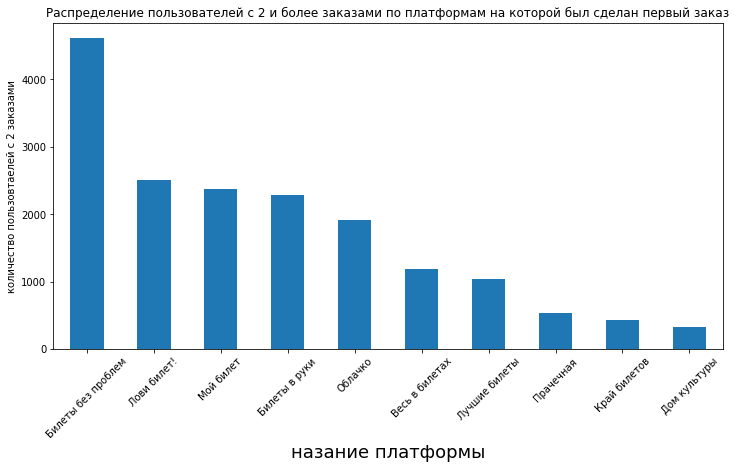

In [54]:
df_segment_service.plot(kind = 'bar',figsize = (12,6),rot = 45)
plt.ylabel('количество пользовтаелей с 2 заказами')
plt.xlabel('назание платформы', fontsize = 18)
plt.title('Распределение пользователей с 2 и более заказами по платформам на которой был сделан первый заказ')
plt.show()

In [55]:
df_segment_region = df_profile.groupby('region_name')['is_two'].sum().sort_values(ascending = False)
df_segment_region = df_segment_region.head(10)
print(df_segment_region)
print(df_segment_region/df_segment_region.sum())

region_name
Каменевский регион      6464
Североярская область    3438
Широковская область     1108
Озернинский край         618
Малиновоярский округ     472
Травяная область         439
Светополянский округ     403
Речиновская область      397
Яблоневская область      375
Медовская область        334
Name: is_two, dtype: int64
region_name
Каменевский регион      0.460137
Североярская область    0.244732
Широковская область     0.078872
Озернинский край        0.043992
Малиновоярский округ    0.033599
Травяная область        0.031250
Светополянский округ    0.028687
Речиновская область     0.028260
Яблоневская область     0.026694
Медовская область       0.023776
Name: is_two, dtype: float64


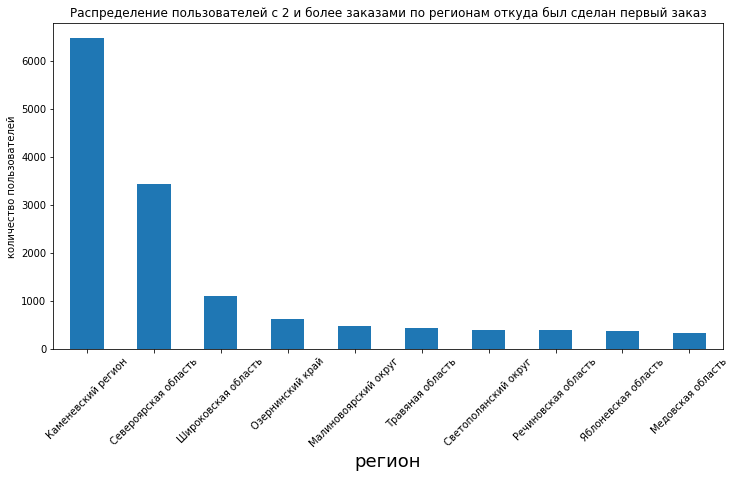

In [56]:
df_segment_region.plot(kind = 'bar',figsize = (12,6),rot = 45)
plt.ylabel('количество пользователей')
plt.xlabel('регион', fontsize = 18)
plt.title('Распределение пользователей с 2 и более заказами по регионам откуда был сделан первый заказ')
plt.show()

In [57]:
df_segment_device = df_profile.groupby('device_type_canonical')['is_two'].sum().sort_values(ascending = False)
df_segment_device = df_segment_device.head(10)
print(df_segment_device)
print(df_segment_device/df_segment_device.sum())

device_type_canonical
mobile     15767
desktop     3356
Name: is_two, dtype: int64
device_type_canonical
mobile     0.824505
desktop    0.175495
Name: is_two, dtype: float64


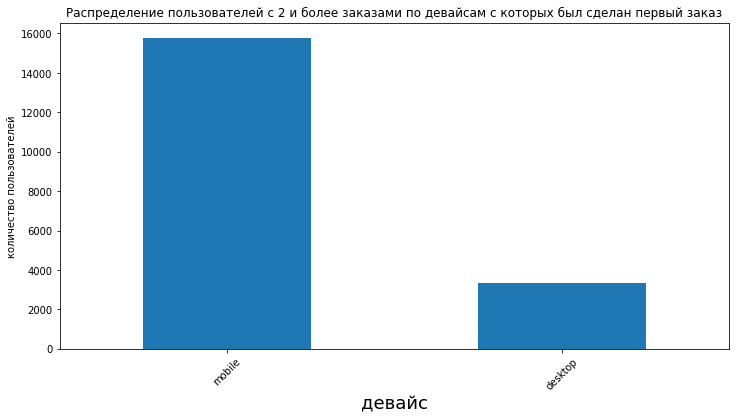

In [58]:
df_segment_device.plot(kind = 'bar',figsize = (12,6),rot = 45)
plt.ylabel('количество пользователей')
plt.xlabel('девайс', fontsize = 18)
plt.title('Распределение пользователей с 2 и более заказами по девайсам с которых был сделан первый заказ')
plt.show()

In [59]:
df_segment_merop = df_profile.groupby('event_type_main')['is_two'].sum().sort_values(ascending = False)
df_segment_merop = df_segment_merop
print(df_segment_merop)
print(df_segment_merop/df_segment_merop.sum())

event_type_main
концерты    8184
другое      4831
театр       3852
стендап     1066
спорт        738
выставки     359
ёлки          93
Name: is_two, dtype: int64
event_type_main
концерты    0.427966
другое      0.252628
театр       0.201433
стендап     0.055744
спорт       0.038592
выставки    0.018773
ёлки        0.004863
Name: is_two, dtype: float64


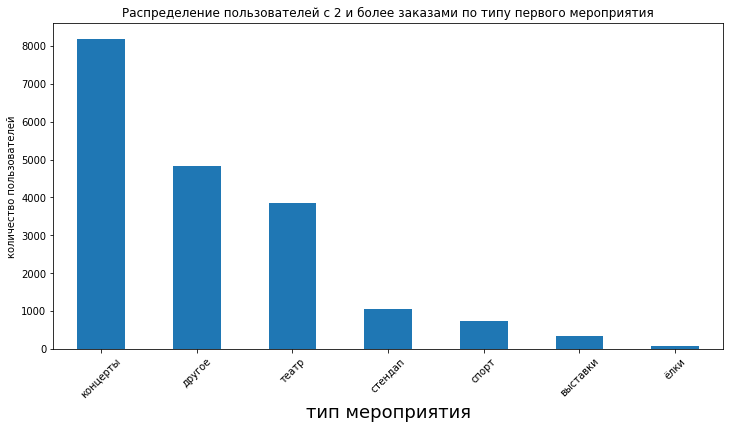

In [60]:
df_segment_merop.plot(kind = 'bar',figsize = (12,6),rot = 45)
plt.ylabel('количество пользователей')
plt.xlabel('тип мероприятия', fontsize = 18)
plt.title('Распределение пользователей с 2 и более заказами по типу первого мероприятия')
plt.show()

По проведенному анализу можно сделать вывод: 

- Больше всего пользователей, которые вернулись ервый раз воспользовались сервисом билеты без проблем их доля 0.27

- Больше всего пользователей, вернувшизся второй раз на Яндекс афишу из Каменевского региона их доля 0.46

- Больше всего пользователей с 2мя и более заказами сделеали 1 заказ с мобильного телефона 0.82

- Больше всего пользоваьелей с 2мя заказами и более в качестве первого мероприятия выбирают концерты их доля 0.43

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [61]:
df_segment = df_segment_merop.reset_index()
df_segment = df_segment.merge(df_profile_event, on = 'event_type_main')
df_segment['back_dola'] = df_segment['is_two']/df_segment['user_id']
df_segment

,event_type_main,is_two,user_id,dola,back_dola
0,концерты,8184,9367,0.434643,0.873706
1,другое,4831,5482,0.254373,0.881248
2,театр,3852,4278,0.198506,0.900421
3,стендап,1066,1117,0.051831,0.954342
4,спорт,738,800,0.037121,0.922500
5,выставки,359,412,0.019117,0.871359
6,ёлки,93,95,0.004408,0.978947


Гипотеза №1 подтвердилась доля тех кто вкрнулся на платформу после первой покупки на спортивные мероприятия выше и составляет 0.92, а доля тех кто вернулся после первой покупки на концерты составляет 0.87 

In [62]:
df_dola_region = df_profile.groupby('region_name')['order_id'].count().sort_values(ascending = False).head(10).reset_index()
df_dola_region = df_dola_region.merge(df_segment_region,on = 'region_name')
df_dola_region['dola'] = df_dola_region['is_two']/df_dola_region['order_id']
df_dola_region


,region_name,order_id,is_two,dola
0,Каменевский регион,7152,6464,0.903803
1,Североярская область,3790,3438,0.907124
2,Широковская область,1239,1108,0.894270
3,Озернинский край,682,618,0.906158
4,Малиновоярский округ,541,472,0.872458
5,Травяная область,489,439,0.897751
6,Светополянский округ,468,403,0.861111
7,Речиновская область,441,397,0.900227
8,Яблоневская область,414,375,0.905797
9,Медовская область,375,334,0.890667


В топ 10 регионов возврат клиента почти не зависит от количесва посещений мероприятий в целом. Регионы с наименьшей долью возврата имеют номер 5, 6, 7:Малиновоярский округ, Травяная область, Светополянский округ соотвнтственно.
     **Гипотеза 2 на подтвердилась**



---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


count    2428.000000
mean      298.548827
std       417.838925
min        -5.385000
25%        68.705833
50%       201.966667
75%       365.910000
max      3871.350000
Name: revenue_rub, dtype: float64
count    19123.000000
mean       610.031856
std        498.285073
min        -10.770000
25%        257.639333
50%        515.398636
75%        826.698333
max       3891.660000
Name: revenue_rub, dtype: float64


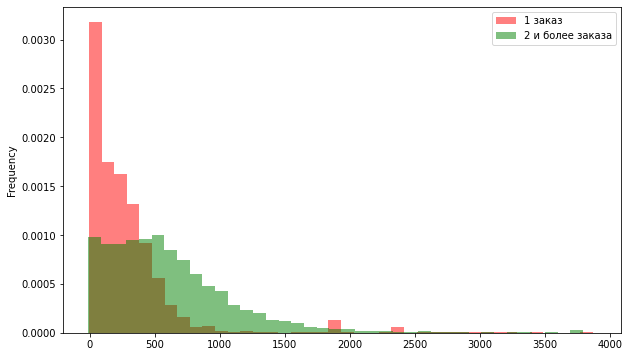

In [63]:
plt.figure(figsize=(10, 6))
one_order = df_profile[df_profile['is_two'] == 0].reset_index()
two_order = df_profile[df_profile['is_two'] == 1].reset_index()
print(one_order['revenue_rub'].describe())
print(two_order['revenue_rub'].describe())
one_order['revenue_rub'].plot(kind = 'hist', bins =40,alpha = 0.5,color = 'red',density = True, label = '1 заказ')
two_order['revenue_rub'].plot(kind = 'hist', bins =40,alpha = 0.5,color = 'green', density = True, label = '2 и более заказа')
plt.legend()
plt.show()

* В первой группе клиентов (1 заказ) с одним закаом значения изменяются от (-5 возмоно ошибка или влияния промокодов и скидок) буем брать 0 до 3871

* Во второй группе (2 и более заказа) клиентов с двумя и более заказами значения изменяются от (-5 возмоно ошибка или влияния промокодов и скидок) буем брать 0 до 3891


* Большое различи между мат ожиданием 298 рублей у первой группы и мат одиданием у второй группы 610 в два раза и медиана у первой группы 201 у второй 515. Возможно такое различие связано с тем что люди с 1 заказам пользуются купоном на бесплатный поход на мероприятие, после этого перестают ходитть на мероприятия

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


count    18439.000000
mean       598.534521
std        481.031621
min        -10.770000
25%        256.811250
50%        512.093548
75%        814.207143
max       3845.620000
Name: revenue_rub, dtype: float64
count     684.000000
mean      919.972433
std       777.825717
min         0.000000
25%       270.075000
50%       710.635000
75%      1427.860000
max      3891.660000
Name: revenue_rub, dtype: float64


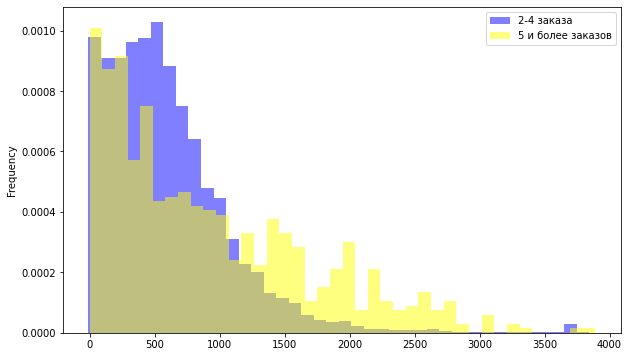

In [64]:
plt.figure(figsize=(10, 6))
two_fore_order = df_profile[(df_profile['is_two'] == 1) & (df_profile['is_five'] == 0)].reset_index()
five_order = df_profile[df_profile['is_five'] == 1].reset_index()
print(two_fore_order['revenue_rub'].describe())
print(five_order['revenue_rub'].describe())
two_fore_order['revenue_rub'].plot(kind = 'hist', bins =40,alpha = 0.5,color = 'b',density = True, label = '2-4 заказа')
five_order['revenue_rub'].plot(kind = 'hist', bins =40,alpha = 0.5,color = 'yellow', density = True, label = '5 и более заказов')
plt.legend()
plt.show()

Да есть различия в среднем значении между группами. В группе 2-4 человека мат ожидание 598,5 рублей. В группе 5 и более человек среднее ожидание 988 рублей и медиана у этой группы выше. Во второй группе больший процент людей, которые берут билеты дороже 1000 рублей, возможно это центели редких мероприятий.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [65]:
df_profile_tickets = df_profile.copy()

In [66]:
df_profile_tickets['tickets_segment'] = pd.cut(df_profile_tickets['tickets_count'],bins =[0,2,3,5,df_profile_tickets['tickets_count'].max()],labels=['1-2','2-3','3-5','>5'])
df_profile_tickets

,user_id,min_created_ts_msk,max_created_ts_msk,device_type_canonical,region_name,service_name,event_type_main,order_id,revenue_rub,tickets_count,avg_time,is_two,is_five,tickets_segment
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaT,1,0,3-5
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,74 days 19:19:38,1,0,2-3
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,50 days 21:45:36,1,0,2-3
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaT,1,0,3-5
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,15 days 14:49:52,0,0,1-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21764,fff13b79bd47d7c,2024-07-16 22:17:10,2024-10-31 18:31:52,mobile,Каменевский регион,Мой билет,другое,9,688.043333,2.555556,13 days 08:31:50.250000,1,0,2-3
21765,fff32fc9ad0f9f6,2024-08-15 14:36:28,2024-10-28 23:40:38,desktop,Каменевский регион,Билеты без проблем,стендап,2,850.995000,2.500000,74 days 09:04:10,1,0,2-3
21766,fffcd3dde79eb2c,2024-06-20 19:57:25,2024-10-30 13:37:43,desktop,Каменевский регион,Билеты без проблем,концерты,33,557.908485,2.787879,4 days 02:48:08.062500,1,0,2-3
21767,fffeeb3c120cf0b,2024-09-24 10:07:42,2024-09-24 10:07:42,desktop,Широковская область,Билеты без проблем,стендап,1,661.530000,2.000000,NaT,1,0,1-2


In [67]:
df_segment_count_ticket = df_profile_tickets.groupby('tickets_segment').agg({'is_two':'sum',
                                                   'user_id':'count'})
df_segment_count_ticket['dola'] = df_segment_count_ticket['is_two']/df_segment_count_ticket['user_id']
df_segment_count_ticket


,is_two,user_id,dola
tickets_segment,,,
1-2,3750,6178,0.606993
2-3,9750,9750,1.000000
3-5,5417,5417,1.000000
>5,206,206,1.000000


    1) Большая часть пользователей пренадлежит сегменту 2-3 бтлета, пользоватей с 5 билетами или больше всего 206.
    2) не возвращабтся только клиенты у которых 1-2 билета в заказе

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [68]:
df_profile_days_of_week = df_profile.copy()
df_profile_days_of_week['first_week'] = df_profile_days_of_week['min_created_ts_msk'].dt.strftime('%A')
df_days_of_week = df_profile_days_of_week.groupby('first_week').agg({'user_id':'count',
                                                                    'is_two':'sum'})
df_days_of_week['dola'] = df_days_of_week['is_two']/df_days_of_week['user_id']
df_days_of_week 


,user_id,is_two,dola
first_week,,,
Friday,3286,2924,0.889836
Monday,2889,2553,0.883697
Saturday,3330,3010,0.903904
Sunday,2788,2461,0.882712
Thursday,3113,2753,0.884356
Tuesday,3101,2752,0.887456
Wednesday,3044,2670,0.877135


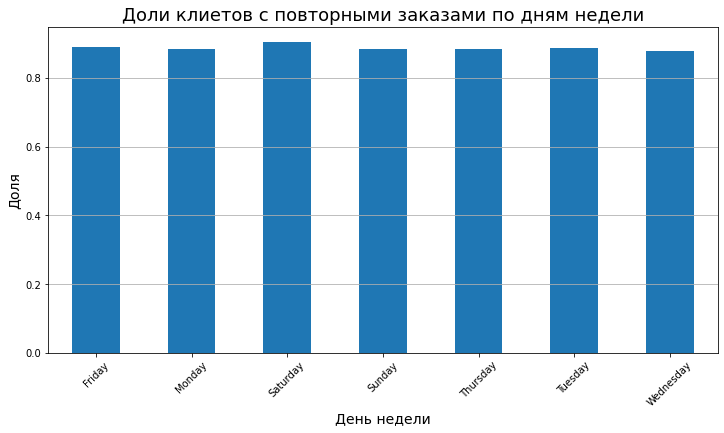

In [69]:
df_days_of_week['dola'].plot(kind = 'bar',rot = 45, figsize = (12,6))
plt.grid(axis = 'y')
plt.title('Доли клиетов с повторными заказами по дням недели', fontsize = 18)
plt.ylabel('Доля',fontsize = 14)
plt.xlabel('День недели',fontsize = 14)
plt.show()

Заметно влияние дня недели первой покупки на возврат клиента на сервис, клиенты сделавшие первый заказ в субботу на 1.5 - 2% чаще возвращаются на платформу чем клиенты сделавшие первый заказ в другой день недели.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [70]:
df_2_4 = df_profile[(df_profile['is_two'] == 1) & (df_profile['is_five'] == 0)]
df_2_4 = df_2_4['avg_time'].mean()
df_5 = df_profile[df_profile['is_five'] == 1]
df_5 = df_5['avg_time'].mean()
print('Среднее время между заказами у клиентов с 2 - 4 заказами', df_2_4)
print('Среднее время между заказами у клиентов с 5 и более заказами', df_5)

Среднее время между заказами у клиентов с 2 - 4 заказами 16 days 07:08:40.782967149
Среднее время между заказами у клиентов с 5 и более заказами 8 days 02:12:33.701682778


По данным выше отчетливо наблюдается, что у людей с 5 и более заказами время между заказами 8 дней, а у людей с 2-4 заказами 16 дней, соответственно люди с меньшем среднем временем заказа вероятнее вернуться за повторным заказом.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [71]:
!pip install phik
from phik import phik_matrix

     |████████████████████████████████| 677 kB 1.4 MB/s eta 0:00:01


In [72]:
import phik
df_profile_1 = df_profile.copy()
df_profile_1['avg_time_seconds'] = df_profile_1['avg_time'].dt.total_seconds()
interval_columns = ['revenue_rub', 'tickets_count', 'avg_time_seconds']
columns_for_phik = [
    'device_type_canonical', 'region_name', 'service_name',
    'event_type_main', 'revenue_rub', 'tickets_count',
    'avg_time_seconds', 'is_two', 'is_five','order_id'
]

df_order_count_phik = df_profile_1[columns_for_phik].phik_matrix(
    interval_cols=interval_columns
)
df_phik = df_order_count_phik.loc[df_order_count_phik.index != 'order_id'][['order_id']].sort_values(by = 'order_id',ascending = False)
df_phik

,order_id
avg_time_seconds,0.494989
tickets_count,0.286047
region_name,0.251033
revenue_rub,0.211083
is_five,0.170603
is_two,0.122150
device_type_canonical,0.060716
service_name,0.000000
event_type_main,0.000000


In [73]:
df_profile_1['order_id'].max() - df_profile_1['order_id'].min()

150

разброс действительно большой, сделаем доп проверку по сегментам

In [85]:
df_profile_1['segment_orders'] = pd.cut(df_profile_1['order_id'],bins =[0,1,4,500],labels=['1','2-4','>5'])
interval_columns_1 = ['revenue_rub', 'tickets_count', 'avg_time_seconds']
columns_for_phik_1 = [
    'device_type_canonical', 'region_name', 'service_name',
    'event_type_main', 'revenue_rub', 'tickets_count',
    'avg_time_seconds', 'is_two', 'is_five','segment_orders'
]
df_order_count_phik_1 = df_profile_1[columns_for_phik_1].phik_matrix(
    interval_cols=interval_columns_1)
df_phik_1 = df_order_count_phik_1.loc[df_order_count_phik_1.index != 'segment_orders'][['segment_orders']].sort_values(by = 'segment_orders',ascending = False)
df_phik_1

,segment_orders
avg_time_seconds,0.388308
tickets_count,0.378937
revenue_rub,0.302084
region_name,0.121421
is_five,0.095766
service_name,0.081369
is_two,0.067373
event_type_main,0.038432
device_type_canonical,0.015140


Тепловая карта значений phi_k для разных сегментов по количеству заказов


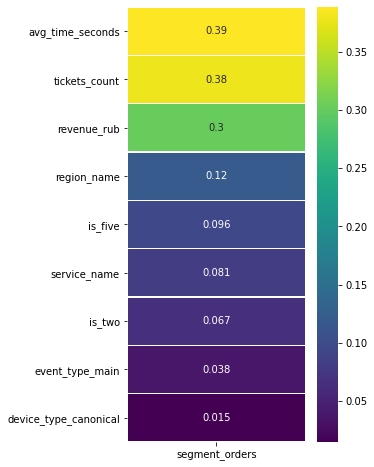

In [86]:
plt.figure(figsize = (4,8))
sns.heatmap(data = df_phik_1,annot = True,linewidth = 0.5,cmap = 'viridis')
print('Тепловая карта значений phi_k для разных сегментов по количеству заказов')
plt.show()

Больше всего с количеством заказов связаны такие признаки как: Среднее время между заказами, среднее количество билетов в заказе и средняя стоймомть заказа в рублях.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Заключение по проделанной работе**

**подготовка материала**
1) В данной работе был составлен ДатаФрейм с профилями Клиентов сервиса Яндекс афиша. 

2) В исходный датафрейм был добавлен столбец с переведенными в рубли стоймостью заказов (Перевод осуществлялся по актуальному курсу на день совершения заказа)

3) Были созданы категориальные столбца с признаками по количеству заказов: 2 зказак и более и 5 заказов и более

4) В приведенных данных в количестве заказов и времени между заказами есть большие выбросы. Данные по количеству заказов будут отфильтроываны по 99 процентилю

**Анализ подготовленного материала**

1)    По совокупности признаков больше всего пользоватклей в качестве первого мероприятия выбрали концерт сделали заказ через телефон в каменевском регионе, влспользоващись сервисом билет без проблем - 754 пользователя или 3 процента. По мероприятия в качестве первого люди в 43 % посещают концерты. По типу первого устройства люди в 83 % случаев выбирают телефон. Больше всего пользователей сделеали первый заказ из Каменского региона. Больше всего пользователей в качестве первого сервиса выбрали билет без проблем 24%. Хочется выделить что все данные преведенные выше можно выделить как особенные точки входа, так как показатели всегда превышают в 2 и более раза следующий по количеству пользователей: сервисы, устройства, регионы и типы мероприятий 

2) Больше всего пользователей, которые вернулись ервый раз воспользовались сервисом билеты без проблем их доля 0.27. Больше всего пользователей, вернувшизся второй раз на Яндекс афишу из Каменевского региона их доля 0.46. Больше всего пользователей с 2мя и более заказами сделеали 1 заказ с мобильного телефона 0.82. Больше всего пользоваьелей с 2мя заказами и более в качестве первого мероприятия выбирают концерты их доля 0.43

3) Доля тех кто вкрнулся на платформу после первой покупки на спортивные мероприятия выше и составляет 0.92, а доля тех кто вернулся после первой покупки на концерты составляет 0.87. В топ 10 регионов возврат клиента почти не зависит от количесва посещений мероприятий в целом. Регионы с наименьшей долью возврата имеют номер 5, 6, 7:Малиновоярский округ, Травяная область, Светополянский округ соотвнтственно.

4) В первой группе клиентов (1 заказ) с одним закаом значения изменяются от (-5 возмоно ошибка или влияния промокодов и скидок) буем брать 0 до 3871. Во второй группе (2 и более заказа) клиентов с двумя и более заказами значения изменяются от (-5 возмоно ошибка или влияния промокодов и скидок) буем брать 0 до 3891. Большое различи между мат ожиданием 298 рублей у первой группы и мат одиданием у второй группы 610 в два раза и медиана у первой группы 201 у второй 515. Возможно такое различие связано с тем что люди с 1 заказам пользуются купоном на бесплатный поход на мероприятие, после этого перестают ходитть на мероприятия

5) Есть различия в среднем значении между группами. В группе 2-4 человека мат ожидание 598,5 рублей. В группе 5 и более человек среднее ожидание 988 рублей и медиана у этой группы выше. Во второй группе больший процент людей, которые берут билеты дороже 1000 рублей, возможно это центели редких мероприятий.

6) Большая часть пользователей пренадлежит сегменту 2-3 бтлета, пользоватей с 5 билетами или больше всего 206. Не возвращабтся только клиенты у которых 1-2 билета в заказе.

7) Заметно влияние дня недели первой покупки на возврат клиента на сервис, клиенты сделавшие первый заказ в субботу на 1.5 - 2% чаще возвращаются на платформу чем клиенты сделавшие первый заказ в другой день недели.

8) По данным выше отчетливо наблюдается, что у людей с 5 и более заказами время между заказами 8 дней, а у людей с 2-4 заказами 16 дней, соответственно люди с меньшем среднем временем заказа вероятнее вернуться за повторным заказом.

9) Больше всего с количеством заказов связаны такие признаки как: Среднее время между заказами, среднее количество билетов в заказе и средняя стоймомть заказа в рублях.

**Рекомендации** 

1) Сделать дополнительную рекламу для пользователей с 2-4 заказами

2) Проверить сервисы с низким количеством возвращений пользователей 

3) Запустить рекламу в городах с низким количеством возвратов пользователей

4) провести опрос пользователей с 1 заказом, узнать почему они не возвращаются на яндекс афишу. Предложить им промокоды, скидки и акции





### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**